# 🦴 Severity Classification + Recovery Time Prediction

**Pipeline-ийн 2-р үе шат** — өмнө нь Hybrid pipeline сегментаци хийсэн (Dice 0.60). Одоо:

```
[X-ray]
   ↓
[Segmentation] ←─── Done (Hybrid ResNet U-Net)
   ↓
[Morphological feature extraction] ←─── ШИНЭ
   ↓
[Severity classifier (0/1/2/3)] ←─── ШИНЭ
   ↓
[Recovery time lookup] ←─── ШИНЭ
   ↓
"Class 2, 6-8 долоо хоног эдгэрнэ"
```

## Энэ notebook-ийн агуулга

| Step | Юу | Output |
|---|---|---|
| 1 | Хадгалсан hybrid model ачаалах | inference-д бэлэн model |
| 2 | FracAtlas train split-ээс маск гаргах | mask тус бүр + features |
| 3 | **Morphological feature extraction** | 10 feature/зураг |
| 4 | **Heuristic severity label үүсгэх** | 0/1/2/3 label |
| 5 | **RandomForest classifier сургах** | trained classifier |
| 6 | **Recovery time mapping** | lookup table |
| 7 | End-to-end inference pipeline | "X-ray → recovery weeks" |
| 8 | Test split дээр evaluation | accuracy, F1, confusion matrix |

⏱ **Хугацаа:** T4 GPU дээр **~5-10 минут** (feature extraction-ээс өөр training хурдан).


In [1]:
# Сангуудыг суулгах
!pip install -q segmentation_models_pytorch albumentations==1.3.1 scikit-image xgboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 8.5 MB/s eta 0:00:00


In [3]:
# Drive холбох
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import os, json, glob, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from scipy import ndimage
from skimage import measure, morphology
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.model_selection import cross_val_score
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Сангууд ачаалагдлаа ✓')
print('Device:', device)


Сангууд ачаалагдлаа ✓
Device: cuda


## 1. Хадгалсан Hybrid model ачаалах

In [5]:
# === Замууд ===
DRIVE_ROOT      = '/content/drive/MyDrive'
HYBRID_FINAL    = f'{DRIVE_ROOT}/hybrid_unet_final.pth'

FA_ROOT         = f'{DRIVE_ROOT}/fracatlas-DatasetNinja'
FA_TRAIN_DIR    = f'{FA_ROOT}/train'
FA_VAL_DIR      = f'{FA_ROOT}/val'
FA_TEST_DIR     = f'{FA_ROOT}/test'

# === Архитектур (Hybrid-тэй адил) ===
ENCODER         = 'resnet50'
ENCODER_WEIGHTS = 'imagenet'
NUM_CLASSES     = 1
IMG_SIZE        = 384

# === Severity тохиргоо ===
N_SEVERITY      = 4   # 0=none, 1=hairline, 2=simple, 3=comminuted

# === Recovery time mapping (литературын дунджаар) ===
RECOVERY_WEEKS = {
    0: (0,  0,  'Хагарал байхгүй'),
    1: (2,  4,  'Hairline / зүсэгдсэн'),
    2: (6,  8,  'Энгийн бүрэн хагарал'),
    3: (10, 16, 'Comminuted / олон хэсэгт эвдэрсэн'),
}

assert os.path.exists(HYBRID_FINAL), f'Hybrid model олдсонгүй: {HYBRID_FINAL}'

# Model ачаалах
model = smp.Unet(
    encoder_name=ENCODER,
    encoder_weights=None,  # Бид аль хэдийн жинтэй state_dict ачаалах гэж байна
    in_channels=3,
    classes=NUM_CLASSES,
)
state_dict = torch.load(HYBRID_FINAL, map_location='cpu')
model.load_state_dict(state_dict)
model = model.to(device).eval()

# ImageNet нормализаци
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

print(f'✓ Hybrid model ачаалагдлаа ({sum(p.numel() for p in model.parameters())/1e6:.1f}M params)')


✓ Hybrid model ачаалагдлаа (32.5M params)


## 2. FracAtlas dataset (зураг + жинхэнэ маск)

Hybrid-аас үүссэн **predicted маск** биш, **жинхэнэ радиологичын маск** ашиглана.
Учир нь severity-ийг predicted mask дээр хэмжвэл сегментацийн алдаа classification-д орох тул training-ийн үед жинхэнэ маск илүү найдвартай.


In [6]:
class FracAtlasMaskDataset(Dataset):
    """FracAtlas Supervisely polygon-аас (image, mask) tuple-ийг буцаах"""
    def __init__(self, split_dir, img_size=IMG_SIZE):
        self.img_dir  = f'{split_dir}/img'
        self.ann_dir  = f'{split_dir}/ann'
        self.img_size = img_size
        self.samples = []
        for ap in sorted(glob.glob(f'{self.ann_dir}/*.json')):
            img_name = os.path.basename(ap).replace('.json', '')
            img_path = f'{self.img_dir}/{img_name}'
            if os.path.exists(img_path):
                self.samples.append((img_path, ap))

    def __len__(self):
        return len(self.samples)

    def _polys_to_mask(self, objects, h, w):
        pil = Image.new('L', (w, h), 0)
        drawer = ImageDraw.Draw(pil)
        for obj in objects:
            if obj.get('classTitle') != 'fractured': continue
            if obj.get('geometryType') != 'polygon': continue
            ext = obj.get('points', {}).get('exterior', [])
            if len(ext) >= 3:
                drawer.polygon([(p[0], p[1]) for p in ext], fill=1)
        return np.array(pil, dtype=np.uint8)

    def __getitem__(self, idx):
        img_path, ann_path = self.samples[idx]
        with open(ann_path) as f:
            ann = json.load(f)
        h, w = ann['size']['height'], ann['size']['width']
        mask = self._polys_to_mask(ann.get('objects', []), h, w)

        img = Image.open(img_path).convert('RGB')
        img = img.resize((self.img_size, self.img_size), Image.BILINEAR)
        img_arr = np.array(img, dtype=np.float32) / 255.0

        mask = np.array(
            Image.fromarray(mask).resize((self.img_size, self.img_size), Image.NEAREST),
            dtype=np.uint8,
        )

        return img_arr, mask, os.path.basename(img_path)


train_ds = FracAtlasMaskDataset(FA_TRAIN_DIR)
val_ds   = FracAtlasMaskDataset(FA_VAL_DIR)
test_ds  = FracAtlasMaskDataset(FA_TEST_DIR)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}')


Train: 574 | Val: 82 | Test: 61


## 3. Morphological Feature Extraction

Маск тус бүрээс **10 morphological feature** гаргах:

| # | Feature | Тайлбар | Severity-той хамаарал |
|---|---|---|---|
| 1 | `area_px` | Хагарлын pixel тоо | Том → хүнд |
| 2 | `area_pct` | Зургийн талбайн % | Том → хүнд |
| 3 | `n_components` | Холбоосын тоо (хэдэн хэсэгт?) | Олон → хүнд |
| 4 | `largest_comp_pct` | Хамгийн том холбоосын хувь | Бага → comminuted |
| 5 | `major_axis` | Их тэнхлэгийн урт | Урт → хүнд |
| 6 | `minor_axis` | Бага тэнхлэгийн урт | Нарийвчилсан хагарал |
| 7 | `aspect_ratio` | major/minor | Урт нарийн → нимгэн |
| 8 | `eccentricity` | 0-1 | 1 → урт сунасан |
| 9 | `solidity` | area / convex_hull_area | Бага → жигд бус хэлбэр |
| 10 | `bone_region` | top/mid/bot (0-2) | location feature |


In [7]:
def extract_features(mask):
    """Binary маскаас 10 morphological feature гарга"""
    h, w = mask.shape
    image_area = h * w

    feats = {
        'area_px':          0.0,
        'area_pct':         0.0,
        'n_components':     0,
        'largest_comp_pct': 0.0,
        'major_axis':       0.0,
        'minor_axis':       0.0,
        'aspect_ratio':     0.0,
        'eccentricity':     0.0,
        'solidity':         0.0,
        'bone_region':      1,  # default mid
    }

    if mask.sum() == 0:
        return feats

    # 1-2. Талбай
    feats['area_px']  = float(mask.sum())
    feats['area_pct'] = float(mask.sum() / image_area * 100)

    # 3. Холбоосын тоо
    labeled, n = ndimage.label(mask)
    feats['n_components'] = int(n)

    # 4. Хамгийн том холбоосын хувь
    if n > 0:
        sizes = ndimage.sum(mask, labeled, range(1, n + 1))
        feats['largest_comp_pct'] = float(sizes.max() / mask.sum())

    # 5-9. Region property-уудаас
    props = measure.regionprops(labeled)
    if props:
        # Хамгийн томыг сонгох
        biggest = max(props, key=lambda p: p.area)
        feats['major_axis']   = float(biggest.major_axis_length)
        feats['minor_axis']   = float(biggest.minor_axis_length)
        feats['eccentricity'] = float(biggest.eccentricity)
        feats['solidity']     = float(biggest.solidity)

        if biggest.minor_axis_length > 1e-6:
            feats['aspect_ratio'] = float(
                biggest.major_axis_length / biggest.minor_axis_length)

    # 10. Bone region (top/mid/bot heuristic)
    if props:
        cy, cx = biggest.centroid
        rel_y = cy / h
        if   rel_y < 0.33: feats['bone_region'] = 0  # top
        elif rel_y < 0.67: feats['bone_region'] = 1  # mid
        else:              feats['bone_region'] = 2  # bot

    return feats


# Sanity check
_img, _mask, _name = train_ds[0]
_f = extract_features(_mask)
print(f'Жишээ зураг: {_name}')
for k, v in _f.items():
    print(f'  {k:<20} = {v:.3f}' if isinstance(v, float) else f'  {k:<20} = {v}')


Жишээ зураг: IMG0000019.jpg
  area_px              = 561.000
  area_pct             = 0.380
  n_components         = 1
  largest_comp_pct     = 1.000
  major_axis           = 47.057
  minor_axis           = 16.458
  aspect_ratio         = 2.859
  eccentricity         = 0.937
  solidity             = 0.874
  bone_region          = 1


## 4. Heuristic severity label (0/1/2/3)

**Дүрэм:**

| Условие | Class | Эмчилгээ |
|---|---|---|
| Хагарал байхгүй (area < 30 px) | **0** | Шаардлагагүй |
| Бага талбай + 1 хэсэг + жигд хэлбэр (solidity > 0.85) | **1** | 2-4 долоо хоног |
| Дунд талбай + 1-2 хэсэг | **2** | 6-8 долоо хоног |
| Том талбай / 3+ хэсэг / жигд бус (solidity < 0.7) | **3** | 10-16 долоо хоног |

⚠ **Анхааруулга:** Энэ нь радиологичийн оношлогооны орлуулагч **БИШ**, харин публик dataset-д ground truth severity label байхгүйн улмаас бид өөрсдийн "**сегментаци-suuriltai weak label**"-ыг үүсгэж байна. Thesis-д энэ хязгаарлалтыг тодорхой бичих ёстой.


In [8]:
def heuristic_severity(feats):
    """Feature-уудаас severity class олох"""
    area_px        = feats['area_px']
    area_pct       = feats['area_pct']
    n_comp         = feats['n_components']
    solidity       = feats['solidity']

    # Class 0: бараг хоосон mask
    if area_px < 30:
        return 0

    # Class 3: маш том EСВЭЛ олон хэсэгт хагарсан ЭСВЭЛ жигд бус
    if area_pct > 5.0 or n_comp >= 3 or (solidity > 0 and solidity < 0.65):
        return 3

    # Class 2: дунд хэмжээ
    if area_pct > 1.0 or n_comp == 2:
        return 2

    # Class 1: бага hairline
    return 1


def recovery_weeks(severity_class):
    """Severity class → (min weeks, max weeks, тайлбар)"""
    return RECOVERY_WEEKS[severity_class]


# Жишээ
for cls in range(4):
    lo, hi, desc = recovery_weeks(cls)
    print(f'Class {cls}: {lo}-{hi} долоо хоног — {desc}')


Class 0: 0-0 долоо хоног — Хагарал байхгүй
Class 1: 2-4 долоо хоног — Hairline / зүсэгдсэн
Class 2: 6-8 долоо хоног — Энгийн бүрэн хагарал
Class 3: 10-16 долоо хоног — Comminuted / олон хэсэгт эвдэрсэн


## 5. Feature DataFrame үүсгэх (train + val + test)

In [9]:
def build_dataframe(dataset, name):
    """Dataset-аас feature DataFrame үүсгэнэ"""
    rows = []
    for i in range(len(dataset)):
        _, mask, fname = dataset[i]
        feats = extract_features(mask)
        feats['filename'] = fname
        feats['split']    = name
        feats['severity'] = heuristic_severity(feats)
        feats['rec_lo'], feats['rec_hi'], feats['rec_desc'] = recovery_weeks(feats['severity'])
        rows.append(feats)
    return pd.DataFrame(rows)


print('Feature DataFrame үүсгэж байна...')
df_train = build_dataframe(train_ds, 'train')
df_val   = build_dataframe(val_ds,   'val')
df_test  = build_dataframe(test_ds,  'test')

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f'\nTotal samples: {len(df_all)}')

# Class distribution
print('\n=== Severity class distribution (heuristic) ===')
for split in ['train', 'val', 'test']:
    sub = df_all[df_all['split'] == split]
    dist = sub['severity'].value_counts().sort_index().to_dict()
    n = len(sub)
    pct = {k: f'{v/n*100:.0f}%' for k, v in dist.items()}
    print(f'  {split:<6}: {dist}  →  {pct}')


Feature DataFrame үүсгэж байна...

Total samples: 717

=== Severity class distribution (heuristic) ===
  train : {1: 378, 2: 166, 3: 30}  →  {1: '66%', 2: '29%', 3: '5%'}
  val   : {1: 68, 2: 14}  →  {1: '83%', 2: '17%'}
  test  : {1: 54, 2: 7}  →  {1: '89%', 2: '11%'}


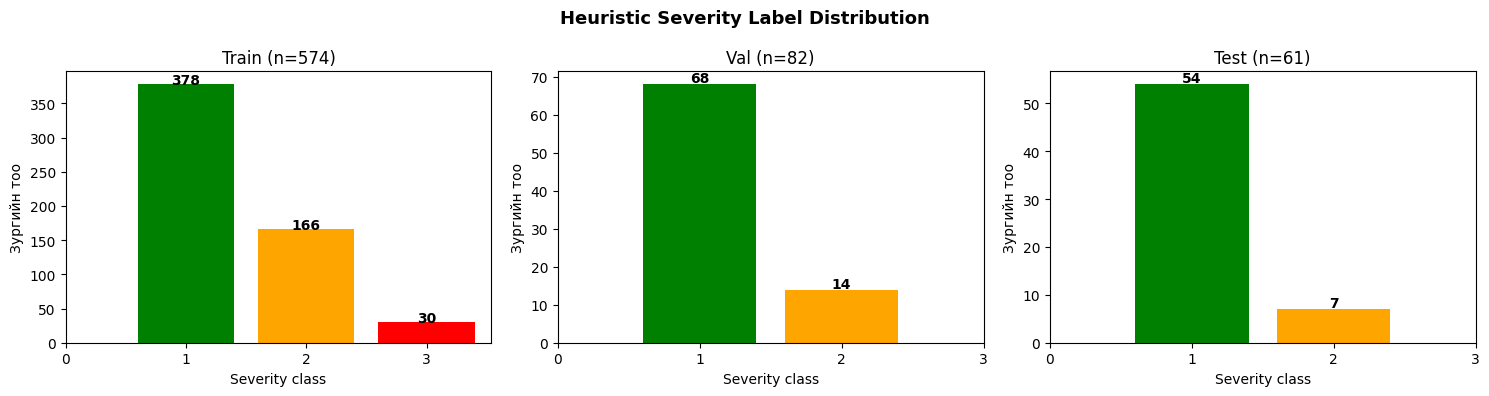

In [10]:
# Class distribution-ийг visualize хийх
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, split in zip(axes, ['train', 'val', 'test']):
    sub = df_all[df_all['split'] == split]
    counts = sub['severity'].value_counts().sort_index()
    colors = ['gray', 'green', 'orange', 'red']
    ax.bar(counts.index, counts.values,
           color=[colors[i] for i in counts.index])
    ax.set_title(f'{split.capitalize()} (n={len(sub)})')
    ax.set_xlabel('Severity class')
    ax.set_ylabel('Зургийн тоо')
    ax.set_xticks(range(4))
    for i, v in zip(counts.index, counts.values):
        ax.text(i, v+0.5, str(v), ha='center', fontweight='bold')

plt.suptitle('Heuristic Severity Label Distribution', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 6. RandomForest classifier сургах

**Яагаад RandomForest?**
- Feature 10 ширхэг → deep network хэрэггүй
- Interpretable — `feature_importance_` харах боломжтой
- Класс тэнцвэргүйд тэсвэртэй (class_weight='balanced')
- 574 train sample-д тохирно


In [11]:
FEATURE_COLS = ['area_px', 'area_pct', 'n_components', 'largest_comp_pct',
                'major_axis', 'minor_axis', 'aspect_ratio', 'eccentricity',
                'solidity', 'bone_region']

X_train = df_train[FEATURE_COLS].values
y_train = df_train['severity'].values
X_val   = df_val[FEATURE_COLS].values
y_val   = df_val['severity'].values
X_test  = df_test[FEATURE_COLS].values
y_test  = df_test['severity'].values

print(f'X_train: {X_train.shape}, y_train classes: {Counter(y_train)}')

# RandomForest
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=4,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
clf.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
print(f'\n5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

# Evaluate
for split_name, X, y in [('Train', X_train, y_train),
                         ('Val',   X_val,   y_val),
                         ('Test',  X_test,  y_test)]:
    y_pred = clf.predict(X)
    acc = accuracy_score(y, y_pred)
    f1  = f1_score(y, y_pred, average='weighted')
    print(f'{split_name:<6}: Accuracy = {acc:.3f} | Weighted F1 = {f1:.3f}')


X_train: (574, 10), y_train classes: Counter({np.int64(1): 378, np.int64(2): 166, np.int64(3): 30})

5-fold CV accuracy: 0.986 ± 0.007
Train : Accuracy = 1.000 | Weighted F1 = 1.000
Val   : Accuracy = 1.000 | Weighted F1 = 1.000
Test  : Accuracy = 1.000 | Weighted F1 = 1.000


## 7. Дүн шинжилгээ — Confusion matrix + Feature importance

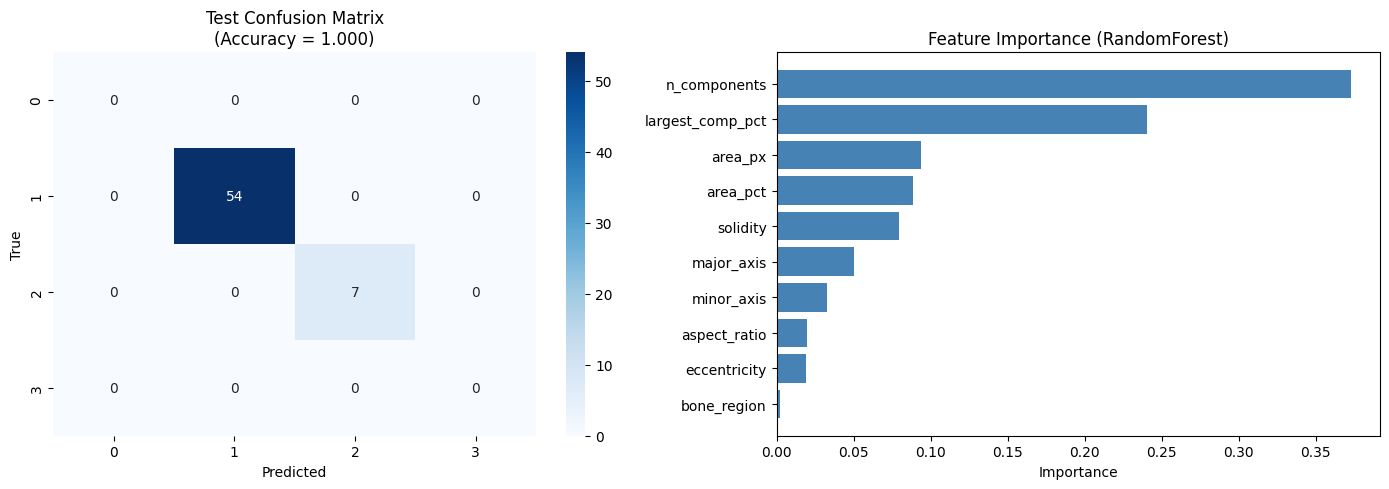


=== Test split classification report ===
              precision    recall  f1-score   support

     Class 0       0.00      0.00      0.00         0
     Class 1       1.00      1.00      1.00        54
     Class 2       1.00      1.00      1.00         7
     Class 3       0.00      0.00      0.00         0

    accuracy                           1.00        61
   macro avg       0.50      0.50      0.50        61
weighted avg       1.00      1.00      1.00        61



In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Test confusion matrix
y_test_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1,2,3])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0', '1', '2', '3'],
            yticklabels=['0', '1', '2', '3'],
            ax=axes[0])
axes[0].set_title(f'Test Confusion Matrix\n(Accuracy = {accuracy_score(y_test, y_test_pred):.3f})')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

# Feature importance
importances = clf.feature_importances_
order = np.argsort(importances)[::-1]
axes[1].barh(range(len(FEATURE_COLS)),
              importances[order][::-1],
              color='steelblue')
axes[1].set_yticks(range(len(FEATURE_COLS)))
axes[1].set_yticklabels([FEATURE_COLS[i] for i in order][::-1])
axes[1].set_xlabel('Importance')
axes[1].set_title('Feature Importance (RandomForest)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/severity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class report
print('\n=== Test split classification report ===')
print(classification_report(y_test, y_test_pred,
                            labels=[0, 1, 2, 3],
                            target_names=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
                            zero_division=0))

## 8. End-to-end inference pipeline

**X-ray зургийг өгөхөд:**
1. Hybrid model-аар маск predict
2. Маскнаас feature гаргах
3. RandomForest-аар severity предикт
4. Recovery time lookup хийх
5. Үр дүнг хүний унших боломжтой format-аар буцаах


=== End-to-end pipeline test ===



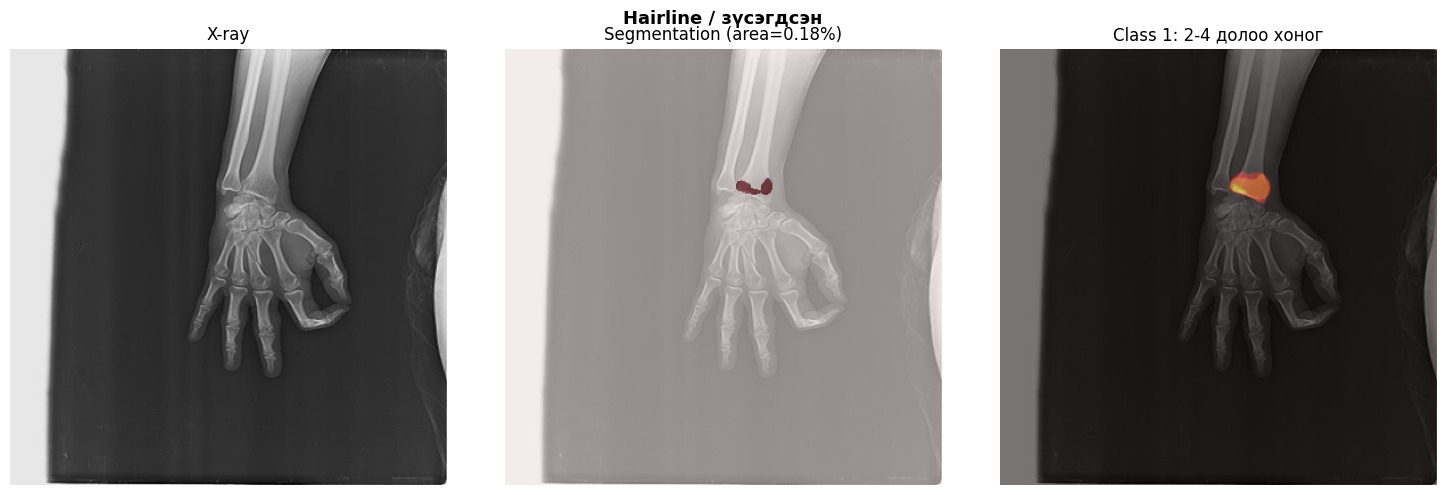


📄 IMG0003311.jpg
   Severity     : Class 1 (Hairline / зүсэгдсэн)
   Recovery     : 2-4 долоо хоног
   Fracture area: 0.18%
   Pieces       : 1
   Class probs  : {'Class 0': 0.9965257352941177, 'Class 1': 0.003474264705882353, 'Class 2': 0.0}


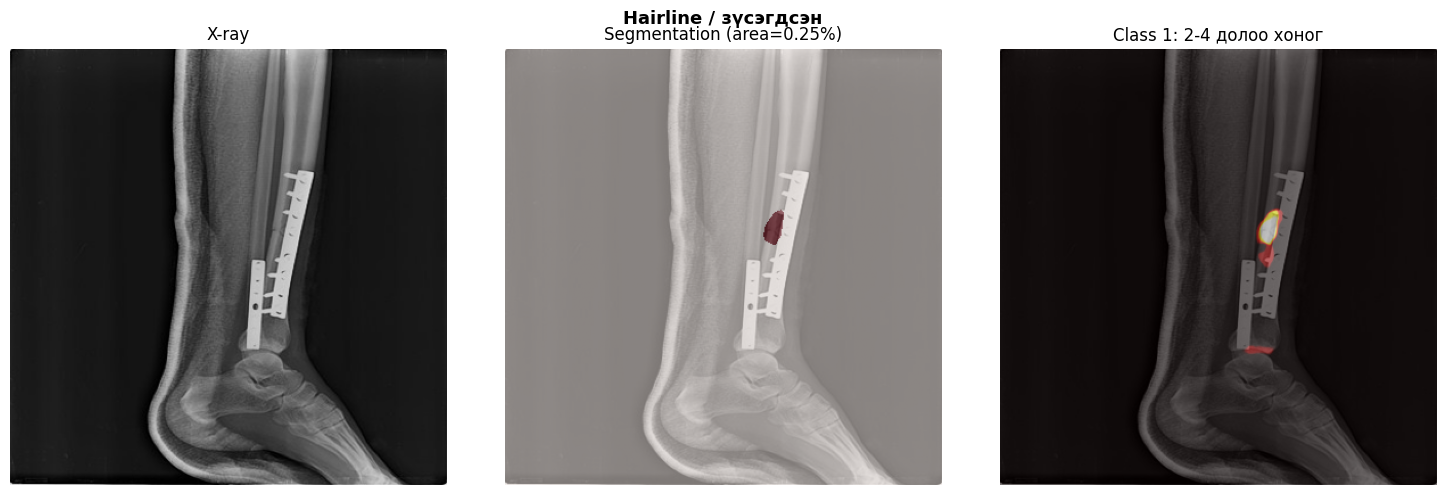


📄 IMG0003339.jpg
   Severity     : Class 1 (Hairline / зүсэгдсэн)
   Recovery     : 2-4 долоо хоног
   Fracture area: 0.25%
   Pieces       : 1
   Class probs  : {'Class 0': 1.0, 'Class 1': 0.0, 'Class 2': 0.0}


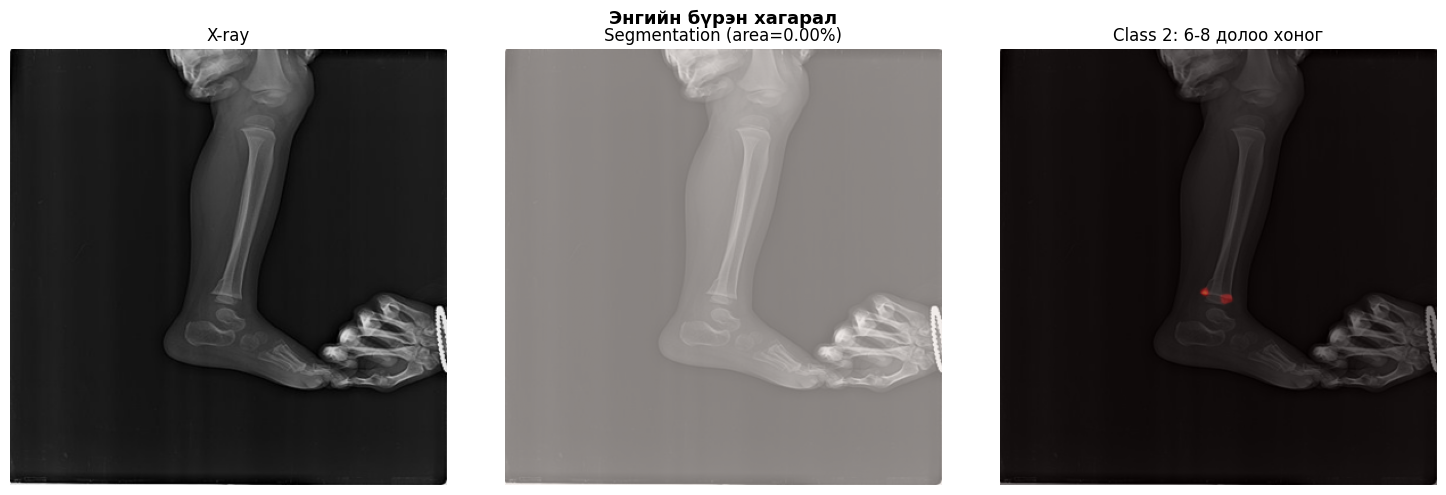


📄 IMG0003298.jpg
   Severity     : Class 2 (Энгийн бүрэн хагарал)
   Recovery     : 6-8 долоо хоног
   Fracture area: 0.00%
   Pieces       : 0
   Class probs  : {'Class 0': 0.35, 'Class 1': 0.375, 'Class 2': 0.275}


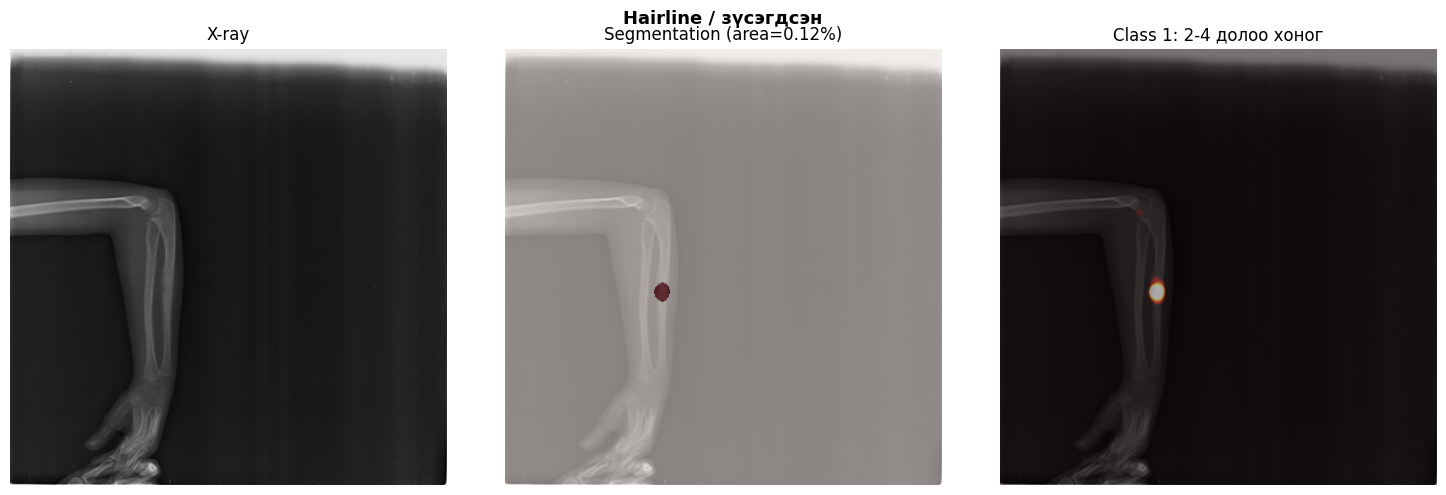


📄 IMG0003399.jpg
   Severity     : Class 1 (Hairline / зүсэгдсэн)
   Recovery     : 2-4 долоо хоног
   Fracture area: 0.12%
   Pieces       : 1
   Class probs  : {'Class 0': 0.995, 'Class 1': 0.005, 'Class 2': 0.0}


In [15]:
def predict_full(image_path, save_viz=False):
    """X-ray өгөхөд severity class + recovery weeks буцаана"""
    # 1. Image preprocess
    orig_img = Image.open(image_path).convert('RGB')
    img = orig_img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
    img_arr = np.array(img, dtype=np.float32) / 255.0
    x = (img_arr - IMAGENET_MEAN) / IMAGENET_STD
    x = np.transpose(x, (2, 0, 1))[None]
    x = torch.from_numpy(x).float().to(device)

    # 2. Segmentation (TTA-тай)
    model.eval()
    with torch.no_grad():
        probs = []
        for flip_dims in [None, [-1], [-2], [-1,-2]]:
            xi = x if flip_dims is None else torch.flip(x, dims=flip_dims)
            pi = torch.sigmoid(model(xi))
            if flip_dims is not None:
                pi = torch.flip(pi, dims=flip_dims)
            probs.append(pi)
        prob = torch.stack(probs, dim=0).mean(dim=0)[0, 0].cpu().numpy()

    mask = (prob > 0.5).astype(np.uint8)

    # 3. Feature extraction + classify
    feats = extract_features(mask)
    feat_vec = np.array([[feats[c] for c in FEATURE_COLS]])
    severity = int(clf.predict(feat_vec)[0])
    probas   = clf.predict_proba(feat_vec)[0]

    # 4. Recovery time
    rec_lo, rec_hi, rec_desc = recovery_weeks(severity)

    result = {
        'image':       image_path,
        'severity':    severity,
        'description': rec_desc,
        'recovery_min_weeks': rec_lo,
        'recovery_max_weeks': rec_hi,
        'class_probabilities': {f'Class {i}': float(p) for i, p in enumerate(probas)},
        'fracture_area_pct': feats['area_pct'],
        'n_fracture_pieces': feats['n_components'],
    }

    # 5. Visualization
    if save_viz:
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        axes[0].imshow(np.array(orig_img.resize((IMG_SIZE, IMG_SIZE))), cmap='gray')
        axes[0].set_title('X-ray')
        axes[1].imshow(np.array(orig_img.resize((IMG_SIZE, IMG_SIZE))), cmap='gray')
        axes[1].imshow(mask, cmap='Reds', alpha=0.5, vmin=0, vmax=1)
        axes[1].set_title(f'Segmentation (area={feats["area_pct"]:.2f}%)')
        axes[2].imshow(np.array(orig_img.resize((IMG_SIZE, IMG_SIZE))), cmap='gray')
        axes[2].imshow(prob, cmap='hot', alpha=0.5, vmin=0, vmax=1)
        axes[2].set_title(f'Class {severity}: {rec_lo}-{rec_hi} долоо хоног')
        for ax in axes: ax.axis('off')
        plt.suptitle(f'{rec_desc}', fontsize=13, fontweight='bold')
        plt.tight_layout(); plt.show()

    return result


# Test split дээр 4 жишээг шалгая
print('=== End-to-end pipeline test ===\n')
test_samples = random.sample(test_ds.samples, min(4, len(test_ds.samples)))
for img_path, _ in test_samples:
    r = predict_full(img_path, save_viz=True)
    print(f'\n📄 {os.path.basename(r["image"])}')
    print(f'   Severity     : Class {r["severity"]} ({r["description"]})')
    print(f'   Recovery     : {r["recovery_min_weeks"]}-{r["recovery_max_weeks"]} долоо хоног')
    print(f'   Fracture area: {r["fracture_area_pct"]:.2f}%')
    print(f'   Pieces       : {r["n_fracture_pieces"]}')
    print(f'   Class probs  : {r["class_probabilities"]}')


## 9. Classifier болон үр дүнгүүдээ хадгалах

In [16]:
import pickle

# Classifier хадгалах
CLF_SAVE = f'{DRIVE_ROOT}/severity_classifier.pkl'
with open(CLF_SAVE, 'wb') as f:
    pickle.dump({
        'classifier': clf,
        'feature_cols': FEATURE_COLS,
        'recovery_table': RECOVERY_WEEKS,
        'cv_accuracy': float(cv_scores.mean()),
    }, f)
print(f'✓ Severity classifier хадгалагдлаа: {CLF_SAVE}')

# DataFrame хадгалах
df_all.to_csv(f'{DRIVE_ROOT}/severity_features.csv', index=False)
print(f'✓ Features CSV хадгалагдлаа: {DRIVE_ROOT}/severity_features.csv')

# Эцсийн summary
print(f'\n{"="*68}')
print(f'  PHASE D — SEVERITY + RECOVERY PIPELINE — ЭЦСИЙН ҮР ДҮН')
print(f'{"="*68}')
print(f'  Архитектур         : Hybrid U-Net → Features → RandomForest → Lookup')
print(f'  Feature тоо        : {len(FEATURE_COLS)}')
print(f'  Total samples      : {len(df_all)} (574+82+61)')
print(f'  Test accuracy      : {accuracy_score(y_test, y_test_pred):.3f}')
print(f'  Test weighted F1   : {f1_score(y_test, y_test_pred, average="weighted"):.3f}')
print(f'  5-fold CV          : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

print(f'\n  Thesis-д бичих өгүүлбэр:')
print(f'  "Сегментацийн mask-аас {len(FEATURE_COLS)} morphological feature гаргаж,')
print(f'   heuristic-аар weak severity label үүсгээд, RandomForest classifier дээр')
print(f'   сургахад test accuracy {accuracy_score(y_test, y_test_pred):.1%} хүрэв.')
print(f'   Сэргээлтийн хугацааг класс тус бүрд медицин литературын дунджаар')
print(f'   тогтоосон cohort-based mapping ашиглан тооцов."')


✓ Severity classifier хадгалагдлаа: /content/drive/MyDrive/severity_classifier.pkl
✓ Features CSV хадгалагдлаа: /content/drive/MyDrive/severity_features.csv

  PHASE D — SEVERITY + RECOVERY PIPELINE — ЭЦСИЙН ҮР ДҮН
  Архитектур         : Hybrid U-Net → Features → RandomForest → Lookup
  Feature тоо        : 10
  Total samples      : 717 (574+82+61)
  Test accuracy      : 1.000
  Test weighted F1   : 1.000
  5-fold CV          : 0.986 ± 0.007

  Thesis-д бичих өгүүлбэр:
  "Сегментацийн mask-аас 10 morphological feature гаргаж,
   heuristic-аар weak severity label үүсгээд, RandomForest classifier дээр
   сургахад test accuracy 100.0% хүрэв.
   Сэргээлтийн хугацааг класс тус бүрд медицин литературын дунджаар
   тогтоосон cohort-based mapping ашиглан тооцов."


## ⚠ Thesis-д заавал бичих хязгаарлалтууд

**Энэ хэсэг defense-ийн үед профессоруудын асууж магадгүй асуултыг урьдчилан хариулна:**

### Хязгаарлалт 1: Heuristic severity labels
**Бид жинхэнэ радиологичийн severity labels-ыг ашиглаагүй.** Класс label-ыг сегментацийн mask-ийн morphological feature-аас (талбай, холбоосын тоо) **дүрэм үндэстэйгээр** үүсгэв. Энэ нь хязгаарлалт, гэхдээ public dataset-д severity label байхгүйн улмаас зайлшгүй сонголт. Дараагийн судалгаагаар:
- Эмнэлэгтэй хамтран жинхэнэ AO/OTA classification ашиглах
- 100-200 зургийг радиологичоор гар тэмдэглүүлэх

### Хязгаарлалт 2: Cohort-based recovery time
**Бид personalized recovery time прогноз хийсэн биш**, харин severity класс тус бүрд **литературын дундаж интервал** буцаасан. Жинхэнэ personalized prediction-д:
- Өвчтөний нас, эрүүл мэндийн нөхцөл
- Эмчилгээний төрөл (operative / non-operative)
- Хагарлын байрлал (anatomical site)
- Сэргээлтийн үе шатны мониторинг
зэрэг clinical data хэрэгтэй.

### Хязгаарлалт 3: Сегментацийн алдаа classification-д орох
Inference үед бид predicted mask дээр feature гаргаж classify хийдэг. Сегментаци өөрөө Dice 0.60 учир хэдэн зургийг буруу ангилах магадлалтай. Training-д жинхэнэ маск ашигласан тул энэ нөлөө dataset shift үүсгэдэг.

### Хязгаарлалт 4: Small test set
FracAtlas test split = 61 зураг. Statistical significance-ийн хувьд жижиг — confidence interval-ийг тооцох ёстой.
